In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
import lightgbm as lgb

from sklearn.metrics import confusion_matrix
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

Temizlenmiş ve birleştirilmiş veri setinin dosya yolunu tanımlanır. Veri setinin satır ve sütun sayısını yazdırır.

In [2]:
csv_path = r"C:\Users\zeyne\Desktop\temiz_veri_seti\birlesik_veri.csv"  
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()


Shape: (4599270, 9)


,hour,passenger_count,vehicle_type,route_code,stop_code,district,is_outlier,is_peak_hour,mean_passenger_by_route_hour
0,0,2,2,KIRAZLI-BASAKSEHIR/METROKENT,RAYLI,BAGCILAR,0,0,1.532982
1,0,2,2,YENIKAPI - HAVALIMANI,RAYLI,BAHCELIEVLER,0,0,2.980226
2,0,1,2,BAHARIYE-OLIMPIYAT,RAYLI,BAKIRKOY,0,0,1.473945
3,0,9,2,KABATAS-BAGCILAR,RAYLI,BAKIRKOY,1,0,3.376855
4,0,2,2,YENIKAPI - HACIOSMAN,RAYLI,BEYOGLU,0,0,2.826446


Hedef değişken olarak yolcu sayısı seçilir.Yolcu sayısını üç seviyeye ayırmak için eşik aralıkları tanımlanır.
0–5: düşük yoğunluk, 5–15: orta yoğunluk, 15+: yüksek yoğunluk
Yolcu sayısı, belirlenen aralıklara göre kategorik sınıflara dönüştürülür

In [3]:
target_col = "passenger_count"

bins = [0, 5, 15, df[target_col].max()]
labels = ["low", "medium", "high"]

df["target_level"] = pd.cut(df[target_col], bins=bins, labels=labels, include_lowest=True)

print(df["target_level"].value_counts(dropna=False))

target_level
low       3624011
medium     590371
high       384888
Name: count, dtype: int64


Kategorik (sayısal olmayan) özellikler tanımlanır. Bu değişkenler model tarafından doğrudan sayısal olarak kullanılamaz,
daha sonra One-Hot Encoding gibi yöntemlerle dönüştürülecektir.Saat bilgisi, yoğunluk göstergeleri ve istatistiksel özetler içerir.
Modelde kullanılacak tüm özellikler birleştirilir.

In [4]:
cat_features = ["route_code", "stop_code", "vehicle_type", "district"]
num_features = ["hour", "is_peak_hour", "is_outlier", "mean_passenger_by_route_hour"]
selected_features = cat_features + num_features

missing = [c for c in selected_features + ["target_level"] if c not in df.columns]
print("Eksik kolon:", missing)

X = df[selected_features]
y = df["target_level"]

Eksik kolon: []


Veri seti eğitim ve test kümelerine ayrılır
%70 eğitim, %30 test olacak şekilde bölme yapılır
stratify=y kullanılarak sınıf dağılımının her iki kümede de korunması sağlanır

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train dağılımı:\n", y_train.value_counts())

Train dağılımı:
 target_level
low       2536808
medium     413260
high       269421
Name: count, dtype: int64


Hedef değişken sayısal forma dönüştürülür
LightGBM ve PyTorch gibi modeller sınıf etiketlerini sayısal beklediği için
low → 0, medium → 1, high → 2 şeklinde etiketleme yapılır

In [6]:
label_map = {"low": 0, "medium": 1, "high": 2}
y_train_num = y_train.map(label_map)
y_test_num  = y_test.map(label_map)

print("y_train unique:", np.unique(y_train_num))
print("y_test unique:", np.unique(y_test_num))

y_train unique: [0 1 2]
y_test unique: [0 1 2]


Veri ön işleme adımı tanımlanır
Kategorik değişkenler One-Hot Encoding ile sayısal forma dönüştürülür
Sayısal değişkenler StandardScaler ile ölçeklendirilir
Kullanılmayan kolonlar veri setinden çıkarılır

In [7]:
preprocess_sparse = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", StandardScaler(), num_features)
    ],
    remainder="drop"
)

Sınıf isimleri ve sayısal etiketleri tanımlanır. Model değerlendirme metrikleri içe aktarılır.
Gerçek ve tahmin edilen etiketlerden confusion matrix hesaplanır, eksenlere sınıf isimlerini eklenir.
Classification report'u sözlük formatında üretildi. Sadece sınıf bazlı metrikler seçildi ve sınıf bazlı performans tablosu gösterildi.

In [8]:
TARGET_NAMES = ["Deniz", "Kara", "Rayli"]
LABELS = [0, 1, 2]

def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(3), TARGET_NAMES)
    plt.yticks(range(3), TARGET_NAMES)
    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i,j], ha="center", va="center")
    plt.show()

def per_class_table(y_true, y_pred, model_name):
    rep = classification_report(
        y_true, y_pred,
        labels=LABELS,
        target_names=TARGET_NAMES,
        output_dict=True,
        zero_division=0
    )
    df = pd.DataFrame(rep).T
    cls_df = df.loc[TARGET_NAMES, ["precision","recall","f1-score","support"]]
    cls_df.insert(0, "Model", model_name)

    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

    display(cls_df)
    plot_cm(y_true, y_pred, f"{model_name} Confusion Matrix")
    return cls_df

LightGBM sınıflandırıcıyı tanımlar. Çok sınıflı sınıflandırma problemi belirtilir.Sınıf sayısı (Deniz / Kara / Rayli)
Tekrarlanabilirlik için sabit tohum sayısı ,ağaç (boosting) sayısı, öğrenme oranı girilir.
Ön işleme + model adımlarını içeren pipeline oluşturulur. Modeli eğitim verisi ile eğitilir.
Test verisi üzerinde tahmin yapılır.  Genel doğruluk (accuracy) hesaplanır.  Sınıflar arası adil değerlendirme için Macro F1 skoru hesaplanır.
Sınıf bazlı performans tablosu ve confusion matrix oluşturulur.

C:\Users\zeyne\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Sistem belirtilen dosyayı bulamıyor
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\zeyne\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\zeyne\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\zeyne\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 3219489, number of used features: 940
[LightGBM] [Info] Start training from score -0.238316
[LightGBM] [Info] Start training from score -2.052901
[LightGBM] [Info] Start training from score -2.480703


C:\Users\zeyne\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== LightGBM BASE ===
Accuracy: 0.8822211640832857
Macro F1: 0.6608511669476823
              precision    recall  f1-score   support

           0     0.9138    1.0000    0.9550   1087203
           1     0.6793    0.1562    0.2540    177111
           2     0.6858    0.8872    0.7736    115467

    accuracy                         0.8822   1379781
   macro avg     0.7596    0.6811    0.6609   1379781
weighted avg     0.8646    0.8822    0.8498   1379781


===== LightGBM (Base) =====
Accuracy: 0.8822211640832857
Macro F1: 0.6608511669476823


,Model,precision,recall,f1-score,support
Deniz,LightGBM (Base),0.913830,0.999963,0.954959,1087203.0
Kara,LightGBM (Base),0.679298,0.156179,0.253968,177111.0
Rayli,LightGBM (Base),0.685803,0.887249,0.773627,115467.0


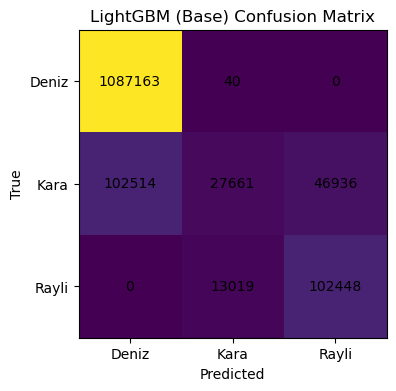

In [9]:
lgbm_base = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    random_state=42,
    n_estimators=400,
    learning_rate=0.1
)

lgbm_pipe_base = Pipeline(steps=[
    ("prep", preprocess_sparse),
    ("model", lgbm_base)
])
lgbm_pipe_base.fit(X_train, y_train_num)
pred_base = lgbm_pipe_base.predict(X_test)
print("=== LightGBM BASE ===")
print("Accuracy:", accuracy_score(y_test_num, pred_base))
print("Macro F1:", f1_score(y_test_num, pred_base, average="macro"))
print(classification_report(y_test_num, pred_base, digits=4))

lgbm_base_df = per_class_table(
    y_test_num,
    pred_base,
    "LightGBM (Base)"
)

Gerçek ve tahmin edilen etiketlerden confusion matrix hesaplar.
labels=[0,1,2] → low, medium, high sınıflarını temsil eder. Her hücrenin içine sayısal değerleri yazılır.

In [10]:
def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    plt.figure(figsize=(4,3))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.xticks([0,1,2], ["low","medium","high"])
    plt.yticks([0,1,2], ["low","medium","high"])

    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()

Sınıflandırma raporunu sözlük formatında üretir. Her sınıf (0,1,2) için precision / recall / f1 / support değerlerini alır.

In [11]:
def class_table_like_screenshot(y_true, y_pred, model_name, class_names=("Deniz","Kara","Rayli")):
    rep = classification_report(y_true, y_pred, output_dict=True, digits=6)

    rows = []
    for i, cname in enumerate(class_names):
        rows.append({
            "": cname,  
            "Model": model_name,
            "precision": rep[str(i)]["precision"],
            "recall": rep[str(i)]["recall"],
            "f1-score": rep[str(i)]["f1-score"],
            "support": rep[str(i)]["support"],
        })

    df = pd.DataFrame(rows).set_index("") 
    return df

Modelin genel doğruluk değeri hesaplanır. Sınıflar arası adil değerlendirme için Macro F1 skoru hesaplanır.

In [12]:
lgbm_bal = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    class_weight="balanced",
    random_state=42,
    n_estimators=400,
    learning_rate=0.1,
    n_jobs=-1
)

lgbm_pipe_bal = Pipeline(steps=[
    ("prep", preprocess_sparse),
    ("model", lgbm_bal)
])

lgbm_pipe_bal.fit(X_train, y_train_num)

pred_bal = lgbm_pipe_bal.predict(X_test)

print("==== LightGBM (Balanced) ====")
print("Accuracy:", accuracy_score(y_test_num, pred_bal))
print("Macro F1:", f1_score(y_test_num, pred_bal, average="macro"))

df_bal = class_table_like_screenshot(
    y_test_num,
    pred_bal,
    model_name="LightGBM (Balanced)",
    class_names=("Deniz", "Kara", "Rayli")
)

df_bal

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2158
[LightGBM] [Info] Number of data points in the train set: 3219489, number of used features: 940
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


C:\Users\zeyne\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


==== LightGBM (Balanced) ====
Accuracy: 0.8483375260276812
Macro F1: 0.6513637487121762


,Model,precision,recall,f1-score,support
,,,,,
Deniz,LightGBM (Balanced),0.922808,0.944394,0.933476,1087203.0
Kara,LightGBM (Balanced),0.337921,0.189232,0.242607,177111.0
Rayli,LightGBM (Balanced),0.656421,0.954879,0.778008,115467.0


Sınıf etiketleri tanımlanır (0: low, 1: medium, 2: high). Gerçek ve tahmin edilen etiketlerden confusion matrix hesaplanır.

In [13]:
def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    labels = [0, 1, 2]
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(4,3))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.xticks([0,1,2], ["low","medium","high"])
    plt.yticks([0,1,2], ["low","medium","high"])

    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()

Sınıf bazlı performans tablosu oluşturan fonksiyon(Deniz / Kara / Raylı için ayrı metrikler)
Classification report'u sözlük formatında üretir. Her sınıf için precision, recall, F1 ve support değerlerini alır.
Elle ayarlanmış (tuned) hiperparametreler ayarlanmıştır: Ağaç sayısı (daha derin öğrenme), Daha yavaş ama daha stabil öğrenme, 
Ağaç karmaşıklığı, Derinlik sınırsız, Aşırı öğrenmeyi azaltır, Satır örnekleme, Özellik örnekleme, L2 regularizasyon 
Ön işleme + Model Pipeline yapılır: Kategorik ve sayısal verilerin ön işlenmesi ve Tuned LightGBM modeli
Modeli Eğitimi yapılır ve Sınıf bazlı performans tablosu oluşturulur.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2136
[LightGBM] [Info] Number of data points in the train set: 3219489, number of used features: 929
[LightGBM] [Info] Start training from score -0.238316
[LightGBM] [Info] Start training from score -2.052901
[LightGBM] [Info] Start training from score -2.480703


C:\Users\zeyne\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM TUNED (FAST) ===
Accuracy: 0.8847237351434757
Macro F1: 0.6752073885491402
              precision    recall  f1-score   support

           0     0.9140    0.9999    0.9550   1087203
           1     0.6935    0.1827    0.2892    177111
           2     0.7047    0.8768    0.7814    115467

    accuracy                         0.8847   1379781
   macro avg     0.7707    0.6865    0.6752   1379781
weighted avg     0.8682    0.8847    0.8550   1379781



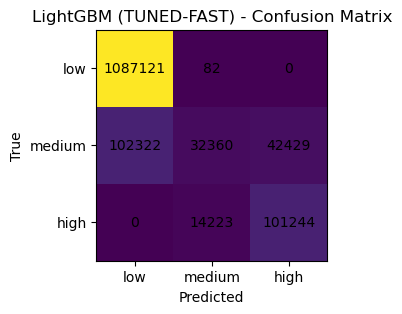

,Model,Class,Precision,Recall,F1,Support
0,LightGBM (Tuned-Fast),Deniz,0.913975,0.999925,0.955020,1087203.0
1,LightGBM (Tuned-Fast),Kara,0.693453,0.182710,0.289218,177111.0
2,LightGBM (Tuned-Fast),Rayli,0.704684,0.876822,0.781385,115467.0


In [14]:
def per_class_table(y_true, y_pred, model_name, class_names=("Deniz","Kara","Rayli")):
    rep = classification_report(y_true, y_pred, output_dict=True, digits=4)
    rows = []
    for i, cname in enumerate(class_names):
        rows.append({
            "Model": model_name,
            "Class": cname,
            "Precision": rep[str(i)]["precision"],
            "Recall": rep[str(i)]["recall"],
            "F1": rep[str(i)]["f1-score"],
            "Support": rep[str(i)]["support"],
        })
    return pd.DataFrame(rows)

lgbm_tuned = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    random_state=42,
    n_jobs=-1,

    n_estimators=800,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
)

lgbm_pipe_tuned = Pipeline(steps=[
    ("prep", preprocess_sparse),
    ("model", lgbm_tuned)
])

lgbm_pipe_tuned.fit(X_train, y_train_num)
pred_tuned = lgbm_pipe_tuned.predict(X_test)

print("\n=== LightGBM TUNED (FAST) ===")
print("Accuracy:", accuracy_score(y_test_num, pred_tuned))
print("Macro F1:", f1_score(y_test_num, pred_tuned, average="macro"))
print(classification_report(y_test_num, pred_tuned, digits=4))

plot_cm(y_test_num, pred_tuned, "LightGBM (TUNED-FAST) - Confusion Matrix")

df_lgbm_tuned = per_class_table(y_test_num, pred_tuned, "LightGBM (Tuned-Fast)")
df_lgbm_tuned

Eğitim verisi için seyrek özellik matrisi oluşturur. Test verisini aynı dönüşümle encode edilir. 
TruncatedSVD ile boyut düşürülür. Sparse matrisler için PCA yerine kullanılır. Eğitim verisinde SVD öğren ve dönüştürülür.
Test verisini aynı SVD uzayına projekte edilir. Boyut düşürülmüş veri matrisinin boyutu kontrol edilir.

In [15]:
X_train_enc = preprocess_sparse.fit_transform(X_train)
X_test_enc  = preprocess_sparse.transform(X_test)

print("Sparse train shape:", X_train_enc.shape)

svd = TruncatedSVD(n_components=128, random_state=42)
X_train_svd = svd.fit_transform(X_train_enc)
X_test_svd  = svd.transform(X_test_enc)

print("Dense train shape:", X_train_svd.shape)


Sparse train shape: (3219489, 976)
Dense train shape: (3219489, 128)


Eğitim ve test feature'ları float32 tensor'a dönüştürülür. Etiketleri long tipinde tensor'a dönüştürülür.
Feature ve label tensor'larını saklayan bir Özel Dataset sınıfı tanımlanır.
Eğitim ve test dataset'lerini oluşturulur. Eğitim verisi için ve Test verisi için DataLoader tanımlanır.

In [16]:
X_train_t = torch.tensor(X_train_svd, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_svd, dtype=torch.float32)

y_train_t = torch.tensor(y_train_num.values, dtype=torch.long)
y_test_t  = torch.tensor(y_test_num.values, dtype=torch.long)

class TabDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabDataset(X_train_t, y_train_t)
test_ds  = TabDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=1024, shuffle=False)

len(train_loader), len(test_loader)

(6289, 1348)

In [17]:
label_map = {"low": 0, "medium": 1, "high": 2}

y_train_num = y_train.map(label_map)
y_test_num  = y_test.map(label_map)

print("y_train_num unique:", np.unique(y_train_num))
print("y_test_num unique:", np.unique(y_test_num))

y_train_num unique: [0 1 2]
y_test_num unique: [0 1 2]


1D Convolution katmanı oluşturulur (girdi: 1 kanal, çıktı: 16 kanal)
İkinci convolution katmanı (16 → 32 kanal) ,Aktivasyon fonksiyonu,  Özellik boyutunu yarıya indiren max pooling, Aşırı öğrenmeyi (overfitting) 
azaltmak için dropout, Fully connected katmanlar, Çıkış katmanı (3 sınıf: low / medium / high) oluşturulur.
(B, F) → (B, 1, F) : Conv1d için kanal eklenir, convolution + ReLU , Pooling ile boyut düşürme, convolution + ReLU, Fully connected katmanlar için 
düzleştir, FC + ReLU + Dropout, Çıkış logits uygulanır.
Çok sınıflı sınıflandırma için CrossEntropyLoss kullanılır. Adam optimizer kullanılır. 

In [18]:
class TabularCNN(nn.Module):
    def __init__(self, n_features=128, n_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.drop = nn.Dropout(0.3)

        self.fc1 = nn.Linear(32 * (n_features // 2), 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)          
        x = self.relu(self.conv1(x))
        x = self.pool(x)            
        x = self.relu(self.conv2(x))
        x = x.flatten(1)            
        x = self.drop(self.relu(self.fc1(x)))
        return self.fc2(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = TabularCNN(n_features=128, n_classes=3).to(device)


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1,2]),
    y=y_train_num.values
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)


device

'cpu'

Modeli değerlendirme (eval) moduna alınır. Tüm tahminleri ve gerçek etiketleri tutacak listeler oluşturulur.
Değerlendirme sırasında gradient hesaplama yapılmaması için no_grad kullanılır.
Verileri kullanılan cihaza (CPU / GPU) taşınır. Model çıktısını (logits) hesaplanır. En yüksek olasılığa sahip sınıfı seçilir.
Tahmin ve gerçek etiketleri CPU'ya alıp listeye eklenir. Doğruluk hesaplanır ve Macro F1 ve gerçek/tahmin etiketleri döndürülür.

In [19]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_true.append(yb.cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_true)
    acc = (y_pred == y_true).mean()
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return acc, macro_f1, y_true, y_pred

Eğitim kaybı (loss), Eğitim doğruluğu (accuracy), Doğrulama kaybı (loss), Doğrulama doğruluğu (accuracy), Doğrulama Macro F1 skoru

In [20]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": []
}

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TabularCNN(n_features=128, n_classes=3).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()

Early stopping için başlangıç değerleri belirtilir. Eğitim döngüsü (Epoch Loop): Toplam loss, Doğru tahmin sayısı, Toplam örnek sayısı belirtilir.
Verileri GPU / CPU'ya taşınır, Önceki gradyanları sıfırla, Kayıp (loss) hesapla, Geri yayılım (backpropagation), Doğru tahmin sayısını artırır.
Metrikler geçmişe kaydedilir. EARLY STOPPING (Macro F1 bazlı), daha iyi bir model bulunduysa kaydedilir. 

In [22]:
best_f1 = 0
patience = 3
pat = 0

for epoch in range(1, 21):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    val_acc, val_macro_f1, _, _ = evaluate(model, test_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_macro_f1)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_acc:.4f} | "
        f"val_acc={val_acc:.4f} "
        f"val_f1={val_macro_f1:.4f}"
    )

    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_state = model.state_dict()
        pat = 0
    else:
        pat += 1
        if pat >= patience:
            print("Early stopping!")
            break

model.load_state_dict(best_state)

Epoch 01 | train_loss=0.3498 train_acc=0.8743 | val_acc=0.8789 val_f1=0.6432
Epoch 02 | train_loss=0.3346 train_acc=0.8774 | val_acc=0.8778 val_f1=0.6227
Epoch 03 | train_loss=0.3296 train_acc=0.8780 | val_acc=0.8793 val_f1=0.6434
Epoch 04 | train_loss=0.3275 train_acc=0.8782 | val_acc=0.8794 val_f1=0.6463
Epoch 05 | train_loss=0.3258 train_acc=0.8788 | val_acc=0.8797 val_f1=0.6514
Epoch 06 | train_loss=0.3253 train_acc=0.8791 | val_acc=0.8798 val_f1=0.6500
Epoch 07 | train_loss=0.3249 train_acc=0.8792 | val_acc=0.8797 val_f1=0.6447
Epoch 08 | train_loss=0.3245 train_acc=0.8792 | val_acc=0.8798 val_f1=0.6428
Early stopping!


<All keys matched successfully>

CNN modelinin eğitim sürecinde doğrulama seti üzerindeki Macro F1 ve Accuracy metriklerinin epoch’lara göre değişimini görselleştirir.

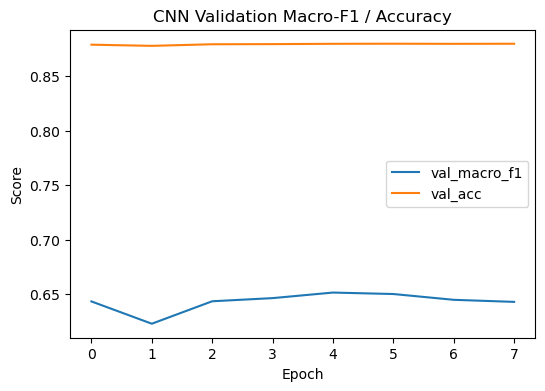

In [23]:
plt.figure(figsize=(6,4))
plt.plot(history["val_macro_f1"], label="val_macro_f1")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("CNN Validation Macro-F1 / Accuracy")
plt.legend()
plt.show()

Model değerlendirmesi yapılır. Genel başarı metrikleri yazdırılır.
Modelin sınıflandırma başarısını özetlemek için Accuracy ve Macro F1 değerleri ekrana yazdırılır.
Sınıf bazlı metrikler hesaplanır. Sınıf bazlı özet tablo hazırlanır
Her sınıf için metrikler bir DataFrame içinde tablo hâline getirilir. En son da Confusion Matrix görselleştirilir.

===== Tabular CNN (SVD-128) =====
Accuracy: 0.879764
Macro F1:  0.642792

Classification Report (digits=8):
              precision    recall  f1-score   support

       Deniz  0.91379474 0.99990066 0.95491055   1087203
        Kara  0.67902654 0.12004336 0.20401877    177111
       Rayli  0.66442725 0.91389748 0.76944671    115467

    accuracy                      0.87976353   1379781
   macro avg  0.75241618 0.67794717 0.64279201   1379781
weighted avg  0.86279118 0.87976353 0.84300428   1379781


Sınıf Bazlı Tablo:


,Model,precision,recall,f1-score,support
Deniz,Tabular CNN (SVD-128),0.913795,0.999901,0.954911,1087203
Kara,Tabular CNN (SVD-128),0.679027,0.120043,0.204019,177111
Rayli,Tabular CNN (SVD-128),0.664427,0.913897,0.769447,115467


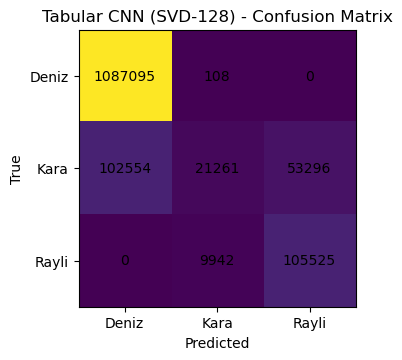

In [24]:
acc, macro_f1, y_true, y_pred = evaluate(model, test_loader)

print("===== Tabular CNN (SVD-128) =====")
print(f"Accuracy: {acc:.6f}")
print(f"Macro F1:  {macro_f1:.6f}")

names = ["Deniz", "Kara", "Rayli"]
labels = [0, 1, 2]

p, r, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)

print("\nClassification Report (digits=8):")
print(classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=names,
    digits=8,
    zero_division=0
))

df_cnn = pd.DataFrame({
    "Model": ["Tabular CNN (SVD-128)"] * 3,
    "precision": p,
    "recall": r,
    "f1-score": f1,
    "support": sup.astype(int),
}, index=names)

df_cnn[["precision","recall","f1-score"]] = df_cnn[["precision","recall","f1-score"]].round(8)

print("\nSınıf Bazlı Tablo:")
display(df_cnn)

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(4.6, 3.6))
plt.imshow(cm)
plt.title("Tabular CNN (SVD-128) - Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks([0,1,2], names)
plt.yticks([0,1,2], names)

for i in range(3):
    for j in range(3):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.show()